In [1]:
from shapely.geometry import box, Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling
import osmnx as ox  
import contextily as ctx
from geopy.geocoders import Nominatim  
from geopy.extra.rate_limiter import RateLimiter
import os
#!pip install h3
import h3
import matplotlib.patches as mpatches

In [2]:
# Get the current working directory
current_path = os.getcwd()

# Define relative paths for data, output, and helper functions
data_in = os.path.join(current_path, "data")       # Folder with input data
output = os.path.join(current_path, "output")      # Folder for saving results

## Green spaces

In [3]:
file_name = 'data/OEFFGRUENFLOGD.json'
gdf_green = gpd.read_file(file_name)
print(gdf_green.columns)
print(len(gdf_green))
print(gdf_green['F_TYP'].value_counts())
gdf_green.head(3)

Index(['id', 'OBJECTID', 'TEXT13ID', 'F_TYP', 'T_TEXT', 'T_LANG', 'O', 'P',
       'O_UEREG', 'O_REGION', 'O_LOKAL', 'P_WLD', 'P_WAS', 'P_WIE', 'P_WGT',
       'P_LW', 'P_PK', 'P_GPK', 'P_GST', 'P_SGR', 'P_AGR', 'P_RGR', 'P_URB',
       'Q_MOB', 'Q_SPI', 'Q_GRI', 'Q_HUN', 'Q_BAB', 'Q_WC', 'Q_SPO', 'Q_TRB',
       'UMFANG', 'FLAECHE', 'SE_ANNO_CAD_DATA', 'geometry'],
      dtype='object')
1936
F_TYP
L    1629
U     171
R     136
Name: count, dtype: int64


,id,OBJECTID,TEXT13ID,F_TYP,T_TEXT,T_LANG,O,P,O_UEREG,O_REGION,...,Q_GRI,Q_HUN,Q_BAB,Q_WC,Q_SPO,Q_TRB,UMFANG,FLAECHE,SE_ANNO_CAD_DATA,geometry
0,OEFFGRUENFLOGD.2289,2289,Währinger Pa*,L,Währinger Park,Währinger Park,1,100000,0,0,...,0,1,0,1,1245,1,1460.941451,57020.131903,None,"MULTIPOLYGON (((16.35083 48.23369, 16.34929 48..."
1,OEFFGRUENFLOGD.2290,2290,Türkenschanz*,L,Türkenschanzplatz,Türkenschanzplatz,1,1,0,0,...,0,0,0,0,0,0,310.900196,2002.715993,None,"POLYGON ((16.32886 48.23482, 16.32824 48.23492..."
2,OEFFGRUENFLOGD.2291,2291,Kongreßpark,L,Kongreßpark/Kainzga,Kainzgasse,1,100000,0,0,...,0,1,0,2,12,1,249.284876,3243.484789,None,"POLYGON ((16.30871 48.22281, 16.30933 48.22285..."


In [4]:
print(gdf_green.crs)
gdf_green = gdf_green[['id', 'F_TYP', 'T_TEXT', 'FLAECHE', 'geometry']]
gdf_green = gdf_green.rename(columns={'FLAECHE': 'original_greenarea',
                                     'geometry': 'geometry_green'})
gdf_green.set_geometry('geometry_green', inplace=True)

gdf_green = gdf_green.to_crs(epsg=31256)
gdf_green['area_m2'] = gdf_green.geometry.area
print(gdf_green.crs)
gdf_green.head(3)

EPSG:4326
EPSG:31256


,id,F_TYP,T_TEXT,original_greenarea,geometry_green,area_m2
0,OEFFGRUENFLOGD.2289,L,Währinger Park,57020.131903,"MULTIPOLYGON (((1388.829 343923.309, 1274.719 ...",57020.220876
1,OEFFGRUENFLOGD.2290,L,Türkenschanzplatz,2002.715993,"POLYGON ((-242.971 344049.152, -288.821 344059...",2002.715999
2,OEFFGRUENFLOGD.2291,L,Kongreßpark/Kainzga,3243.484789,"POLYGON ((-1740.791 342714.09, -1694.181 34271...",3243.484798


In [5]:
print(len(gdf_green))
print("Sum green areas - from Flaeche:", gdf_green["original_greenarea"].sum())
print("Sum green areas - my calculation:", gdf_green['area_m2'].sum())

1936
Sum green areas - from Flaeche: 174781716.3472637
Sum green areas - my calculation: 177485054.0345264


## Census districts

In [6]:
boundaries_path = 'data/ZAEHLBEZIRKOGDPolygon.shp'
census_boundaries = gpd.read_file(boundaries_path)
print(census_boundaries.crs)
census_boundaries = census_boundaries.to_crs(epsg=31256)
census_boundaries.head(3)

EPSG:4326


,BEZNR,ZBEZNR,BEZ,ZBEZ,FLAECHE,UMFANG,AKT_TIMEST,SE_SDO_ROW,geometry
0,22.0,19.0,22,2219,431562.4878,2963.93,2025-05-10,305665.0,"POLYGON ((9534.781 343188.416, 9466.411 343046..."
1,19.0,9.0,19,1909,700939.3051,3670.56,2025-05-10,305666.0,"POLYGON ((419.711 344179.176, 419.451 344291.5..."
2,9.0,2.0,09,0902,471286.9574,3510.43,2025-05-10,305667.0,"POLYGON ((2280.931 343474.716, 2281.161 343474..."


In [7]:
censusnames_path = 'data/namen-zbez.csv'
censusnames = gpd.read_file(censusnames_path)
# print(census_boundaries.crs)
# census_boundaries = census_boundaries.to_crs(epsg=31256)
censusnames.head(3)

,NUTS1,NUTS2,NUTS3,DISTRICT_CODE,SUB_DISTRICT_CODE_STATA,SUB_DISTRICT_CODE_VIE,NAME_STATA,NAME_VIE
0,AT1,AT13,AT130,90100,9010101,90101,Altstadt-Ost,Altstadt-Ost
1,AT1,AT13,AT130,90100,9010102,90102,Stubenviertel,Stubenviertel
2,AT1,AT13,AT130,90100,9010103,90103,Opernviertel,Opernviertel


In [8]:
# Step 1: Extract last 4 digits from the SUB_DISTRICT_CODE_VIE
censusnames['ZBEZ'] = censusnames['SUB_DISTRICT_CODE_VIE'].astype(str).str[-4:]

# Step 2: Merge with census_boundaries on ZBEZ
census_boundaries = census_boundaries.merge(
    censusnames[['ZBEZ', 'NAME_STATA']], 
    on='ZBEZ',
    how='left'
)

census_boundaries.head(3)


,BEZNR,ZBEZNR,BEZ,ZBEZ,FLAECHE,UMFANG,AKT_TIMEST,SE_SDO_ROW,geometry,NAME_STATA
0,22.0,19.0,22,2219,431562.4878,2963.93,2025-05-10,305665.0,"POLYGON ((9534.781 343188.416, 9466.411 343046...",Stadlau
1,19.0,9.0,19,1909,700939.3051,3670.56,2025-05-10,305666.0,"POLYGON ((419.711 344179.176, 419.451 344291.5...",Döblinger Cottage
2,9.0,2.0,09,0902,471286.9574,3510.43,2025-05-10,305667.0,"POLYGON ((2280.931 343474.716, 2281.161 343474...",Roßau


In [9]:
census_boundaries = census_boundaries[['ZBEZ', 'FLAECHE', 'geometry', 'NAME_STATA']]
census_boundaries = census_boundaries.rename(columns={'FLAECHE': 'original_censusarea',
                                                     'geometry': 'geometry_census' ,
                                                     'NAME_STATA': 'census_name'})
census_boundaries.set_geometry('geometry_census', inplace=True)
census_boundaries['area_boundaries'] = census_boundaries.geometry.area
census_boundaries.head(3)

,ZBEZ,original_censusarea,geometry_census,census_name,area_boundaries
0,2219,431562.4878,"POLYGON ((9534.781 343188.416, 9466.411 343046...",Stadlau,431562.489038
1,1909,700939.3051,"POLYGON ((419.711 344179.176, 419.451 344291.5...",Döblinger Cottage,700939.307083
2,0902,471286.9574,"POLYGON ((2280.931 343474.716, 2281.161 343474...",Roßau,471286.958700


In [10]:
print(len(census_boundaries))
print("Sum census district areas - from Flaeche:", census_boundaries["original_censusarea"].sum())
print("Sum census district areas - my calculation:", census_boundaries['area_boundaries'].sum())

250
Sum census district areas - from Flaeche: 414870565.6894
Sum census district areas - my calculation: 414870566.8331835


In [11]:
print(census_boundaries.crs)
print(gdf_green.crs)

EPSG:31256
EPSG:31256


In [12]:
# green area per census district
green_in_census = gpd.overlay(census_boundaries, gdf_green, how='intersection')
# green_in_census = gpd.overlay(census_boundaries, gdf_green, how='intersection', keep_geom_type=False)
print(len(green_in_census))
print(green_in_census.isnull().sum())
green_in_census['new_green_area'] = green_in_census.geometry.area
print("Original green area:", gdf_green['area_m2'].sum())
print("Green area after overlay:", green_in_census['new_green_area'].sum())
green_in_census.head(3)

2414
ZBEZ                   0
original_censusarea    0
census_name            0
area_boundaries        0
id                     0
F_TYP                  0
T_TEXT                 0
original_greenarea     0
area_m2                0
geometry               0
dtype: int64
Original green area: 177485054.0345264
Green area after overlay: 126944693.16638353


,ZBEZ,original_censusarea,census_name,area_boundaries,id,F_TYP,T_TEXT,original_greenarea,area_m2,geometry,new_green_area
0,2219,431562.4878,Stadlau,431562.489038,OEFFGRUENFLOGD.2676,L,Mühlgrund,76517.700862,76517.701080,"MULTIPOLYGON (((9103.751 342516.125, 9116.158 ...",247.320048
1,2219,431562.4878,Stadlau,431562.489038,OEFFGRUENFLOGD.2677,L,Hausgrun dweg,2739.814240,2739.814248,"POLYGON ((9466.411 343046.736, 9466.404 343046...",2737.393493
2,2219,431562.4878,Stadlau,431562.489038,OEFFGRUENFLOGD.2678,L,Vernholzgasse,5103.515597,5103.515612,"POLYGON ((8986.451 343400.036, 8995.931 343420...",158.497458


In [13]:
green_in_census = green_in_census.sort_values(by=['ZBEZ', 'id']).reset_index(drop=True)
green_in_census.head(5)

# grouping green areas based on their id to check whether same green area is divided into multiple census districts
green_in_census.groupby('id').size().reset_index(name='count').sort_values(by='count', ascending=False).head(20)
print("Sum green areas per census district - after my groupby:", green_in_census["new_green_area"].sum())

#print(green_in_census[green_in_census['id']== 'OEFFGRUENFLOGD.3713']['new_area'].sum())
#green_in_census[green_in_census['id']== 'OEFFGRUENFLOGD.3713']
print(len(green_in_census))
print(green_in_census['ZBEZ'].nunique())
green_in_census.head(3)

Sum green areas per census district - after my groupby: 126944693.16638353
2414
248


,ZBEZ,original_censusarea,census_name,area_boundaries,id,F_TYP,T_TEXT,original_greenarea,area_m2,geometry,new_green_area
0,0101,377461.6586,Altstadt-Ost,377461.659643,OEFFGRUENFLOGD.2838,L,Dr.-Karl-Lueger-Platz,1804.722495,1804.722500,"POLYGON ((3496.99 341023.561, 3494.089 341024....",37.070825
1,0101,377461.6586,Altstadt-Ost,377461.659643,OEFFGRUENFLOGD.3308,R,DonaukanalFranzJosefskai,7193.400254,7193.400274,"POLYGON ((3486.181 341497.856, 3487.921 341497...",1139.957538
2,0102,379376.7503,Stubenviertel,379376.751348,OEFFGRUENFLOGD.2347,R,Stadtpark,108386.138482,108386.138793,"MULTIPOLYGON (((3723.931 340853.976, 3721.311 ...",69630.066640


In [14]:
# Step 1: Get mean area per F_TYP
mean_area = green_in_census.groupby('F_TYP')['new_green_area'].mean().reset_index()
mean_area.columns = ['F_TYP', 'mean_area']

# Step 2: Get idx of min and max per F_TYP
idx_min = green_in_census.groupby('F_TYP')['new_green_area'].idxmin()
idx_max = green_in_census.groupby('F_TYP')['new_green_area'].idxmax()

# Step 3: Retrieve rows at those indices
min_rows = green_in_census.loc[idx_min, ['F_TYP', 'new_green_area', 'ZBEZ']]
min_rows.columns = ['F_TYP', 'min_area', 'min_zbez']

max_rows = green_in_census.loc[idx_max, ['F_TYP', 'new_green_area', 'ZBEZ']]
max_rows.columns = ['F_TYP', 'max_area', 'max_zbez']

# Step 4: Merge all results
summary = mean_area.merge(min_rows, on='F_TYP').merge(max_rows, on='F_TYP')

# Step 5: Optional – round area columns and sort
summary[['mean_area', 'min_area', 'max_area']] = summary[['mean_area', 'min_area', 'max_area']].round(2)
summary = summary.sort_values(by='mean_area', ascending=False).reset_index(drop=True)

# Count number of occurrences for each F_TYP
ftyp_counts = green_in_census['F_TYP'].value_counts().reset_index()
ftyp_counts.columns = ['F_TYP', 'count']

# Merge with your existing summary
summary = summary.merge(ftyp_counts, on='F_TYP')

# Reorder columns if you like
summary = summary[['F_TYP', 'count', 'mean_area', 'min_area', 'min_zbez', 'max_area', 'max_zbez']]

display(summary)

,F_TYP,count,mean_area,min_area,min_zbez,max_area,max_zbez
0,U,249,389269.12,0.01,2117,20282506.43,1310
1,R,233,40825.85,0.01,2101,895192.35,1301
2,L,1932,10612.97,0.00,1704,656508.93,1112


In [15]:
## identifying lost green areas (50million m2)
# green areas that has no intersect with census district boundaries at all
lost_green_ids = set(gdf_green['id']) - set(green_in_census['id'])
print(f"Number of green areas that is not in any census district: {len(lost_green_ids)}")
print(f"Green areas that is not in any census district: {lost_green_ids}")


green_clipped_per_id = green_in_census.groupby('id')['new_green_area'].sum().reset_index()
total_full_green_area = gdf_green['area_m2'].sum()

green_area_comparison = gdf_green[['id', 'area_m2']].merge(green_clipped_per_id, on='id', how='left')
green_area_comparison['new_green_area'] = green_area_comparison['new_green_area'].fillna(0)
green_area_comparison['loss_m2'] = green_area_comparison['area_m2'] - green_area_comparison['new_green_area']
green_area_comparison['loss_pct'] = (green_area_comparison['loss_m2'] / green_area_comparison['area_m2']) * 100

Number of green areas that is not in any census district: 53
Green areas that is not in any census district: {'OEFFGRUENFLOGD.3913', 'OEFFGRUENFLOGD.4059', 'OEFFGRUENFLOGD.3930', 'OEFFGRUENFLOGD.3916', 'OEFFGRUENFLOGD.3993', 'OEFFGRUENFLOGD.3864', 'OEFFGRUENFLOGD.3908', 'OEFFGRUENFLOGD.3871', 'OEFFGRUENFLOGD.4004', 'OEFFGRUENFLOGD.4067', 'OEFFGRUENFLOGD.3867', 'OEFFGRUENFLOGD.3961', 'OEFFGRUENFLOGD.3872', 'OEFFGRUENFLOGD.3929', 'OEFFGRUENFLOGD.3940', 'OEFFGRUENFLOGD.3898', 'OEFFGRUENFLOGD.3914', 'OEFFGRUENFLOGD.3923', 'OEFFGRUENFLOGD.3920', 'OEFFGRUENFLOGD.3918', 'OEFFGRUENFLOGD.3858', 'OEFFGRUENFLOGD.4010', 'OEFFGRUENFLOGD.3870', 'OEFFGRUENFLOGD.3876', 'OEFFGRUENFLOGD.3897', 'OEFFGRUENFLOGD.3906', 'OEFFGRUENFLOGD.3862', 'OEFFGRUENFLOGD.3878', 'OEFFGRUENFLOGD.3855', 'OEFFGRUENFLOGD.3912', 'OEFFGRUENFLOGD.3881', 'OEFFGRUENFLOGD.3905', 'OEFFGRUENFLOGD.3879', 'OEFFGRUENFLOGD.3874', 'OEFFGRUENFLOGD.3931', 'OEFFGRUENFLOGD.3917', 'OEFFGRUENFLOGD.3854', 'OEFFGRUENFLOGD.3860', 'OEFFGRUENFLOGD.

In [16]:
print(len(green_area_comparison))
green_area_comparison.head()

1936


,id,area_m2,new_green_area,loss_m2,loss_pct
0,OEFFGRUENFLOGD.2289,57020.220876,57020.220876,7.785275e-10,1.365353e-12
1,OEFFGRUENFLOGD.2290,2002.715999,2002.715999,-1.271701e-09,-6.349882e-11
2,OEFFGRUENFLOGD.2291,3243.484798,3243.484798,-3.210516e-10,-9.898355e-12
3,OEFFGRUENFLOGD.2292,5086.636449,5086.636449,-3.637979e-12,-7.152032e-14
4,OEFFGRUENFLOGD.2293,4592.970413,4592.970413,0.000000e+00,0.000000e+00


In [17]:
nogreen_districts = set(census_boundaries['ZBEZ']) - set(green_in_census['ZBEZ'])
# Filter the relevant rows from census_boundaries
nogreen_area_df = census_boundaries[census_boundaries['ZBEZ'].isin(nogreen_districts)]

print(nogreen_area_df[['ZBEZ', 'census_name', 'area_boundaries']])
print(f"Census districts with no green area: {nogreen_districts}")
print(f"Number of green areas that is not in any census district: {len(lost_green_ids)}")

     ZBEZ                              census_name  area_boundaries
66   2231  Industriegebiet Erzherzog Karl - Straße    289396.619546
200  2120                       Shuttleworthstraße    504422.680385
Census districts with no green area: {'2231', '2120'}
Number of green areas that is not in any census district: 53


In [69]:
green_area_per_census = green_in_census.groupby('ZBEZ')['new_green_area'].sum().reset_index()
print("Sum green areas per census district - my calculation, after groupby:", green_area_per_census["new_green_area"].sum())

# Merge with ALL census boundaries — keeps all 250
green_area_per_census = census_boundaries[['ZBEZ', 'area_boundaries', 'geometry_census', 'census_name']].merge(
    green_area_per_census, on='ZBEZ', how='left'
)

# fill missing values with 0 (districts with no green space)
green_area_per_census['new_green_area'] = green_area_per_census['new_green_area'].fillna(0)

# green ratio calculation
green_area_per_census['green_ratio'] = green_area_per_census['new_green_area'] / green_area_per_census['area_boundaries']

print(len(green_area_per_census))
print(green_area_per_census.isnull().sum())
green_area_per_census.head(3)

Sum green areas per census district - my calculation, after groupby: 126944693.16638355
250
ZBEZ               0
area_boundaries    0
geometry_census    0
census_name        0
new_green_area     0
green_ratio        0
dtype: int64


,ZBEZ,area_boundaries,geometry_census,census_name,new_green_area,green_ratio
0,2219,431562.49,"POLYGON ((9534.781 343188.416, 9466.411 343046...",Stadlau,3143.21,7.28e-03
1,1909,700939.31,"POLYGON ((419.711 344179.176, 419.451 344291.5...",Döblinger Cottage,9485.05,1.35e-02
2,0902,471286.96,"POLYGON ((2280.931 343474.716, 2281.161 343474...",Roßau,33699.29,7.15e-02


In [70]:
# Number of census districts where green_ratio > 1
problem_count_g = (green_area_per_census['green_ratio'] > 1).sum()
print("Districts with green_ratio > 1:", problem_count_g)

Districts with green_ratio > 1: 0


## Including socio-economic variables

In [71]:
data_ssi = gpd.read_file('data/data_ssi.geojson')
print(data_ssi.crs)
print(len(data_ssi))

data_ssi = data_ssi.to_crs(epsg=31256)
data_ssi['area_ssi'] = data_ssi.geometry.area
# data_ssi = data_ssi[['ZBEZ', 'area_ssi']]
data_ssi.head(5)

EPSG:4326
246


,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry,area_ssi
0,0101,1.60,1.74,1.13,1.12,1.65,5,"POLYGON ((3485.019 341498.126, 3484.459 341498...",377557.21
1,0102,1.65,2.57,1.24,1.14,2.00,5,"POLYGON ((3487.789 341009.066, 3470.019 341017...",379376.75
2,0103,1.71,3.81,1.64,1.23,2.57,5,"POLYGON ((2735.149 340257.116, 2743.919 340257...",465496.86
3,0104,1.85,3.16,1.70,1.31,2.41,5,"POLYGON ((2313.839 340611.086, 2356.209 340648...",835823.05
4,0105,1.68,2.42,1.19,1.25,1.97,5,"POLYGON ((2639.529 341630.546, 2697.199 341592...",333293.04


In [74]:
# Merge green ratios with data_ssi (socio-economic variables)
merged_census = green_area_per_census.merge(
    data_ssi, on='ZBEZ', how='left'  # preserve all districts from green_area_per_census
)

missing_ssi = merged_census[merged_census['geometry'].isna()]
#print("Districts missing in data_ssi:", missing_ssi['ZBEZ', 'census_name', 'area_boundaries'].tolist())



# Select desired columns and convert to list of rows
print("Districts missing in data_ssi:")
print(missing_ssi[['ZBEZ', 'census_name', 'area_boundaries']].values.tolist())


print(merged_census['new_green_area'].sum())
print("Green Area max:", (merged_census["new_green_area"].max() / 1e6).round(3), "km²",
      "| ZBEZ:", merged_census.loc[merged_census["new_green_area"].idxmax(), "ZBEZ"])
merged_census.head(3)

Districts missing in data_ssi:
[['2230', 'noname (9220130)', 26081795.913150962], ['1310', 'Lainzer Tiergarten', 23494760.79426872], ['0210', 'noname (9020110)', 1250097.63260326], ['2130', 'noname (9210129)', 727609.451245093]]
126944693.16638356
Green Area max: 22.422 km² | ZBEZ: 2230


,ZBEZ,area_boundaries,geometry_census,census_name,new_green_area,green_ratio,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry,area_ssi
0,2219,431562.49,"POLYGON ((9534.781 343188.416, 9466.411 343046...",Stadlau,3143.21,7.28e-03,-0.82,-0.67,-0.28,-0.51,-0.70,2.0,"POLYGON ((9548.449 343216.676, 9477.569 343253...",429854.04
1,1909,700939.31,"POLYGON ((419.711 344179.176, 419.451 344291.5...",Döblinger Cottage,9485.05,1.35e-02,1.86,2.01,1.16,1.14,1.86,5.0,"POLYGON ((419.719 344179.166, 420.099 343999.9...",700939.31
2,0902,471286.96,"POLYGON ((2280.931 343474.716, 2281.161 343474...",Roßau,33699.29,7.15e-02,1.53,0.39,0.87,0.97,1.05,5.0,"POLYGON ((2280.939 343474.706, 2280.809 343475...",471286.96


In [22]:
# Drop rows where 'income' or 'unemployed_rate' is NaN
census_final = merged_census.dropna(subset=['avg_income', 'unemprate'])
print(len(census_final))
print(census_final['new_green_area'].sum())
print("Green Area max:", (census_final["new_green_area"].max() / 1e6).round(3), "km²",
      "| ZBEZ:", census_final.loc[census_final["new_green_area"].idxmin(), "ZBEZ"])
census_final.head(3)

246
82170714.99490605
Green Area max: 17.169 km² | ZBEZ: 2231


,ZBEZ,area_boundaries,geometry_census,new_green_area,green_ratio,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry,area_ssi
0,2219,431562.489038,"POLYGON ((9534.781 343188.416, 9466.411 343046...",3143.210999,0.007283,-0.824343,-0.666530,-0.279051,-0.514422,-0.698326,2.0,"POLYGON ((9548.449 343216.676, 9477.569 343253...",429854.038477
1,1909,700939.307083,"POLYGON ((419.711 344179.176, 419.451 344291.5...",9485.049730,0.013532,1.861136,2.007536,1.161796,1.140429,1.857084,5.0,"POLYGON ((419.719 344179.166, 420.099 343999.9...",700939.307152
2,0902,471286.958700,"POLYGON ((2280.931 343474.716, 2281.161 343474...",33699.286438,0.071505,1.534756,0.389211,0.873002,0.970293,1.052743,5.0,"POLYGON ((2280.939 343474.706, 2280.809 343475...",471286.958747


## Blue spaces

In [23]:
admin_city = ox.geocode_to_gdf('Vienna')
# admin_city.plot()
# plt.show()
# admin_city.to_file("dataframes/admin_city_vienna.geojson", driver="GeoJSON")

# Define the polygon for the administrative 
admin_poly = admin_city.geometry.values[0]

# Download POIs for blue spaces within the administrative boundary
tags_blue = {
    'natural': ['water', 'wetland'],
    'waterway': ['river', 'canal'], # 'stream' should be included or not? 
    'water': ['pond', 'lake', 'reservoir', 'basin', 'fishpond']
}
blue = ox.features_from_polygon(admin_poly, tags=tags_blue)

print(admin_city.crs)
print(blue.crs)
print("Water sources:", len(blue))
print("Type of data:", type(blue))
blue.head(3)

epsg:4326
epsg:4326
Water sources: 1014
Type of data: <class 'geopandas.geodataframe.GeoDataFrame'>


source  \
element_type osmid                 
node         6813960988      NaN   
way          3870590     landsat   
             3870688     landsat   

                                                                  geometry  \
element_type osmid                                                           
node         6813960988                          POINT (16.41034 48.13083)   
way          3870590     POLYGON ((16.49867 48.27628, 16.4991 48.27635,...   
             3870688     POLYGON ((16.42203 48.23973, 16.42207 48.23983...   

                        created_by odbl river:waterway_distance waterway  \
element_type osmid                                                         
node         6813960988        NaN  NaN                     NaN      NaN   
way          3870590           NaN  NaN                     NaN      NaN   
             3870688           NaN  NaN                     NaN      NaN   

                        seamark:type                 name maxwidth obstacle  \
element_type osmid                                                            
node         6813960988          NaN                  NaN      NaN      NaN   
way          3870590             NaN  Transportbetongrube      NaN      NaN   
             3870688             NaN     Schießstattlacke      NaN      NaN   

                         ... year_of_construction toilets:wheelchair memorial  \
element_type osmid       ...                                                    
node         6813960988  ...                  NaN                NaN      NaN   
way          3870590     ...                  NaN                NaN      NaN   
             3870688     ...                  NaN                NaN      NaN   

                        fence_type abandoned  lit ways attraction name:sh  \
element_type osmid                                                          
node         6813960988        NaN       NaN  NaN  NaN        NaN     NaN   
way          3870590           NaN       NaN  NaN  NaN        NaN     NaN   
             3870688           NaN       NaN  NaN  NaN        NaN     NaN   

                        species:wikidata  
element_type osmid                        
node         6813960988              NaN  
way          3870590                 NaN  
             3870688                 NaN  

[3 rows x 130 columns]

In [24]:
from shapely.ops import unary_union
blue = blue.to_crs(epsg=31256)
print(blue.crs)
city_boundary = unary_union(census_boundaries.geometry)
urban_blue_spaces = gpd.clip(blue, city_boundary)

print(type(city_boundary))
print(city_boundary.is_empty)

EPSG:31256
<class 'shapely.geometry.polygon.Polygon'>
False


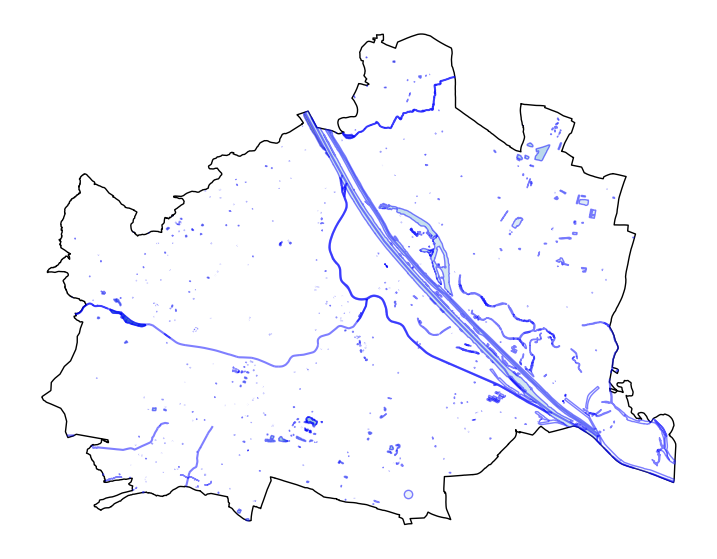

In [25]:
# plot blue spaces, ensure true crs for all (31256)
admin_city = admin_city.to_crs(epsg=31256)

if not urban_blue_spaces.empty:
    fig, ax = plt.subplots(1,1, figsize=(9, 9))
    admin_city.plot(ax=ax, color='none', edgecolor='k')
    urban_blue_spaces.plot(ax=ax, cmap='Blues', alpha=0.5, edgecolor='blue')
    ax.set_aspect('equal')
    ax.axis('off')
    plt.show()
else:
    print("⚠️ Clipping removed all blue space geometries. Check CRS and boundaries.")

In [26]:
print(urban_blue_spaces.geometry.type.unique())
print(len(urban_blue_spaces))
# in order to overlay, I need same types of geometries
# seperate blue geometries into 2 different gdf: blue_lines, blue_areas

# Separate blue space geometries by type
blue_areas = urban_blue_spaces[urban_blue_spaces.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
blue_lines = urban_blue_spaces[urban_blue_spaces.geometry.type.isin(['LineString', 'MultiLineString'])].copy()

print(blue_areas.geometry.type.unique())
print(blue_lines.geometry.type.unique())
print("Number of blue areas:", len(blue_areas))
print("Number of blue lines:", len(blue_lines))

['MultiLineString' 'Polygon' 'LineString' 'MultiPolygon' 'Point']
1012
['Polygon' 'MultiPolygon']
['MultiLineString' 'LineString']
Number of blue areas: 939
Number of blue lines: 72


In [27]:
# examining blue lines
print(blue_lines.columns.to_list())
cols_of_interest = [
    'river:waterway_distance', 'waterway', 'man_made', 'seasonal', 'tidal', 'wetland',
    'maxwidth', 'width', 'est_width'
]
subset_lines = blue_lines[cols_of_interest]

print("Waterway:", blue_lines['waterway'].notna().sum())
print("Man-made:", blue_lines['man_made'].notna().sum())
print("Seasonal:", blue_lines['seasonal'].notna().sum())
print("Tidal:", blue_lines['tidal'].notna().sum())
print("Wetland:", blue_lines['wetland'].notna().sum())

['source', 'geometry', 'created_by', 'odbl', 'river:waterway_distance', 'waterway', 'seamark:type', 'name', 'maxwidth', 'obstacle', 'seamark:name', 'note', 'name:cs', 'tourism', 'wheelchair', 'wikidata', 'wikipedia', 'alt_name', 'name:de', 'name:es', 'name:sk', 'natural', 'access', 'barrier', 'layer', 'drinking_water', 'intermittent', 'leisure', 'name:en', 'name:fr', 'name:hu', 'man_made', 'material', 'operator', 'operator:wikidata', 'ref', 'website', 'amenity', 'artist_name', 'description', 'image', 'height', 'sport', 'reservoir_type', 'water', 'width', 'name:br', 'wikimedia_commons', 'nodes', 'landuse', 'boat', 'name:nl', 'name:pl', 'loc_name', 'CEMT', 'name:eu', 'name:ku', 'name:uk', 'source:name:br', 'fishing', 'salt', 'tidal', 'name:ro', 'name:ru', 'name:sr', 'depth', 'est_width', 'seamark:harbour:category', 'source:alt_name', 'check_date', 'heritage', 'heritage:operator', 'ref:at:bda', 'ref:wien:kultur', 'name:hr', 'name:bg', 'covered', 'tunnel', 'location', 'substance', 'disused

In [28]:
blue_lines['waterway'].value_counts()

waterway
canal    42
river    30
Name: count, dtype: int64

In [29]:
# Ensure numeric conversion
blue_lines['maxwidth'] = pd.to_numeric(blue_lines['maxwidth'], errors='coerce')
blue_lines['width'] = pd.to_numeric(blue_lines['width'], errors='coerce')
blue_lines['est_width'] = pd.to_numeric(blue_lines['est_width'], errors='coerce')

print("Average maxwidth:", pd.to_numeric(blue_lines['maxwidth'], errors='coerce').mean())
print("Average width:", pd.to_numeric(blue_lines['width'], errors='coerce').mean())
print("Average est_width:", pd.to_numeric(blue_lines['est_width'], errors='coerce').mean())

Average maxwidth: 24.0
Average width: 15.0
Average est_width: 15.0


In [30]:
# examining blue areas
print(blue_areas.columns.to_list())
subset_area = blue_areas[cols_of_interest]

print("Waterway:", blue_areas['waterway'].notna().sum())
print("Man-made:", blue_areas['man_made'].notna().sum())
print("Seasonal:", blue_areas['seasonal'].notna().sum())
print("Tidal:", blue_areas['tidal'].notna().sum())
print("Wetland:", blue_areas['wetland'].notna().sum())

['source', 'geometry', 'created_by', 'odbl', 'river:waterway_distance', 'waterway', 'seamark:type', 'name', 'maxwidth', 'obstacle', 'seamark:name', 'note', 'name:cs', 'tourism', 'wheelchair', 'wikidata', 'wikipedia', 'alt_name', 'name:de', 'name:es', 'name:sk', 'natural', 'access', 'barrier', 'layer', 'drinking_water', 'intermittent', 'leisure', 'name:en', 'name:fr', 'name:hu', 'man_made', 'material', 'operator', 'operator:wikidata', 'ref', 'website', 'amenity', 'artist_name', 'description', 'image', 'height', 'sport', 'reservoir_type', 'water', 'width', 'name:br', 'wikimedia_commons', 'nodes', 'landuse', 'boat', 'name:nl', 'name:pl', 'loc_name', 'CEMT', 'name:eu', 'name:ku', 'name:uk', 'source:name:br', 'fishing', 'salt', 'tidal', 'name:ro', 'name:ru', 'name:sr', 'depth', 'est_width', 'seamark:harbour:category', 'source:alt_name', 'check_date', 'heritage', 'heritage:operator', 'ref:at:bda', 'ref:wien:kultur', 'name:hr', 'name:bg', 'covered', 'tunnel', 'location', 'substance', 'disused

In [31]:
blue_areas['wetland'].value_counts()

wetland
reedbed       123
marsh          10
swamp           6
wet_meadow      5
Name: count, dtype: int64

In [32]:
print("Average maxwidth:", pd.to_numeric(blue_areas['maxwidth'], errors='coerce').mean())
print("Average width:", pd.to_numeric(blue_areas['width'], errors='coerce').mean())
print("Average est_width:", pd.to_numeric(blue_areas['est_width'], errors='coerce').mean())

Average maxwidth: nan
Average width: nan
Average est_width: nan


In [33]:
# Choose a reasonable buffer (in meters = 10meters) to be on the safe side
blue_lines_buffered = blue_lines.copy()
blue_lines_buffered = blue_lines_buffered.to_crs(epsg=31256)
blue_lines_buffered['geometry'] = blue_lines_buffered.buffer(10)  # buffer in projected CRS

# Combine with actual polygons
blue_areas_total = pd.concat([blue_areas, blue_lines_buffered], ignore_index=True)
print(len(blue_areas_total))
blue_areas_total.head(3)

1011


/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_23168/963941783.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  blue_areas_total = pd.concat([blue_areas, blue_lines_buffered], ignore_index=True)


,source,geometry,created_by,odbl,river:waterway_distance,waterway,seamark:type,name,maxwidth,obstacle,...,year_of_construction,toilets:wheelchair,memorial,fence_type,abandoned,lit,ways,attraction,name:sh,species:wikidata
0,NaN,"POLYGON ((18220.629 334014.735, 18219.861 3340...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,"[132057205, 132057207, 132057208, 132057204]",NaN,NaN,NaN
1,NaN,"POLYGON ((17462.506 333997.675, 17470.506 3339...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,"POLYGON ((14616.91 335143.58, 14667.745 335160...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,"[146466307, 149719527, 966204119, 277313617, 2...",NaN,NaN,NaN


In [34]:
# blue areas per district
print(blue_areas_total.crs)
print(green_area_per_census.crs)
green_area_per_census.head(3)

EPSG:31256
EPSG:31256


,ZBEZ,area_boundaries,geometry_census,new_green_area,green_ratio
0,2219,431562.489038,"POLYGON ((9534.781 343188.416, 9466.411 343046...",3143.210999,0.007283
1,1909,700939.307083,"POLYGON ((419.711 344179.176, 419.451 344291.5...",9485.049730,0.013532
2,0902,471286.958700,"POLYGON ((2280.931 343474.716, 2281.161 343474...",33699.286438,0.071505


In [35]:
blue_proj = blue_areas_total.to_crs(green_area_per_census.crs)
blue_in_census = gpd.overlay(census_boundaries, blue_proj, how='intersection')
print(len(blue_in_census))
print(blue_in_census.columns.to_list())
blue_in_census = blue_in_census.sort_values(by=['ZBEZ']).reset_index(drop=True)
blue_in_census.head(5)

1166
['ZBEZ', 'original_censusarea', 'census_name', 'area_boundaries', 'source', 'created_by', 'odbl', 'river:waterway_distance', 'waterway', 'seamark:type', 'name', 'maxwidth', 'obstacle', 'seamark:name', 'note', 'name:cs', 'tourism', 'wheelchair', 'wikidata', 'wikipedia', 'alt_name', 'name:de', 'name:es', 'name:sk', 'natural', 'access', 'barrier', 'layer', 'drinking_water', 'intermittent', 'leisure', 'name:en', 'name:fr', 'name:hu', 'man_made', 'material', 'operator', 'operator:wikidata', 'ref', 'website', 'amenity', 'artist_name', 'description', 'image', 'height', 'sport', 'reservoir_type', 'water', 'width', 'name:br', 'wikimedia_commons', 'nodes', 'landuse', 'boat', 'name:nl', 'name:pl', 'loc_name', 'CEMT', 'name:eu', 'name:ku', 'name:uk', 'source:name:br', 'fishing', 'salt', 'tidal', 'name:ro', 'name:ru', 'name:sr', 'depth', 'est_width', 'seamark:harbour:category', 'source:alt_name', 'check_date', 'heritage', 'heritage:operator', 'ref:at:bda', 'ref:wien:kultur', 'name:hr', 'name:b

,ZBEZ,original_censusarea,census_name,area_boundaries,source,created_by,odbl,river:waterway_distance,waterway,seamark:type,...,toilets:wheelchair,memorial,fence_type,abandoned,lit,ways,attraction,name:sh,species:wikidata,geometry
0,0101,377461.6586,Altstadt-Ost,377461.659643,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((3129.5 340894.761, 3128.393 340893.5..."
1,0102,379376.7503,Stubenviertel,379376.751348,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,"[182056515, 146984835, 891579199, 905421159, 9...",NaN,NaN,NaN,"MULTIPOLYGON (((3602.221 341478.906, 3604.001 ..."
2,0102,379376.7503,Stubenviertel,379376.751348,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,"[9023665, 191072125]",NaN,NaN,NaN,"POLYGON ((3548.672 340733.107, 3550.418 340734..."
3,0102,379376.7503,Stubenviertel,379376.751348,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((3645.249 340872.379, 3642.968 340871..."
4,0102,379376.7503,Stubenviertel,379376.751348,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((3921.192 341440.676, 3921.187 341440..."


In [36]:
blue_in_census = blue_in_census.rename(columns={'area': 'original_blue_area'})
blue_in_census['original_blue_area'] = pd.to_numeric(blue_in_census['original_blue_area'], errors='coerce')
blue_in_census['blue_new_area'] = blue_in_census.geometry.area
blue_in_census['blue_new_area'] = pd.to_numeric(blue_in_census['blue_new_area'], errors='coerce')

In [37]:
blue_in_census = blue_in_census[['ZBEZ', 'original_censusarea', 'area_boundaries', 
                                 'original_blue_area', 'blue_new_area', 'geometry']]

print(len(blue_in_census))
# print("Sum of green areas:", blue_in_census['new_green_area'].sum()) # it has duplicates
print("Sum of original blue areas:", blue_in_census['original_blue_area'].sum())
print("Sum of new blue areas:", blue_in_census['blue_new_area'].sum())

blue_in_census.head(3)

1166
Sum of original blue areas: 0.0
Sum of new blue areas: 18749088.470138825


,ZBEZ,original_censusarea,area_boundaries,original_blue_area,blue_new_area,geometry
0,0101,377461.6586,377461.659643,NaN,16.971625,"POLYGON ((3129.5 340894.761, 3128.393 340893.5..."
1,0102,379376.7503,379376.751348,NaN,3.624606,"MULTIPOLYGON (((3602.221 341478.906, 3604.001 ..."
2,0102,379376.7503,379376.751348,NaN,3415.834089,"POLYGON ((3548.672 340733.107, 3550.418 340734..."


In [38]:
# blue area per census district
blue_area_per_census = blue_in_census.groupby('ZBEZ')['blue_new_area'].sum().reset_index()
print("Sum blue areas per census district - my calculation, after groupby:", blue_area_per_census["blue_new_area"].sum())
print(len(blue_area_per_census))
blue_area_per_census.head(5)

Sum blue areas per census district - my calculation, after groupby: 18749088.470138825
160


,ZBEZ,blue_new_area
0,0101,16.971625
1,0102,56987.074366
2,0103,20253.261827
3,0104,944.004931
4,0106,50.734933


In [39]:
noblue_districts = set(census_boundaries['ZBEZ']) - set(blue_in_census['ZBEZ'])
print(f"Number of census districts without any blue area: {len(noblue_districts)}")
#print(f"Census districts with no blue area: {noblue_districts}")

Number of census districts without any blue area: 90


In [40]:
# Merge with ALL census boundaries & green area features — keeps all 250
blue_area_per_census = green_area_per_census.merge(
    blue_area_per_census, on='ZBEZ', how='left'
)

# fill missing values with 0 (districts with no blue space)
blue_area_per_census['blue_new_area'] = blue_area_per_census['blue_new_area'].fillna(0)

# blue ratio calculation
blue_area_per_census['blue_ratio'] = blue_area_per_census['blue_new_area'] / blue_area_per_census['area_boundaries']

blue_area_per_census = blue_area_per_census.sort_values(by=['ZBEZ']).reset_index(drop=True)

print(len(blue_area_per_census))
print(blue_area_per_census.isnull().sum())
blue_area_per_census.head(3)

250
ZBEZ               0
area_boundaries    0
geometry_census    0
new_green_area     0
green_ratio        0
blue_new_area      0
blue_ratio         0
dtype: int64


,ZBEZ,area_boundaries,geometry_census,new_green_area,green_ratio,blue_new_area,blue_ratio
0,0101,377461.659643,"POLYGON ((3485.011 341498.136, 3486.181 341497...",1177.028363,0.003118,16.971625,0.000045
1,0102,379376.751348,"POLYGON ((3487.781 341009.076, 3521.041 341061...",77665.401597,0.204718,56987.074366,0.150212
2,0103,465496.860336,"POLYGON ((2735.141 340257.126, 2714.401 340256...",25072.878241,0.053863,20253.261827,0.043509


In [41]:
# Number of census districts where blue_ratio > 1
problem_count_b = (blue_area_per_census['blue_ratio'] > 1).sum()
print("Districts with blue_ratio > 1:", problem_count_b)
print("Districts with green_ratio > 1:", (blue_area_per_census['green_ratio'] > 1).sum())
print("Total green area:", blue_area_per_census['new_green_area'].sum())
print("Total blue area:", blue_area_per_census['blue_new_area'].sum())

Districts with blue_ratio > 1: 0
Districts with green_ratio > 1: 0
Total green area: 126944693.16638355
Total blue area: 18749088.470138825


In [42]:
# Merge green-blue gdf with data_ssi (socio-economic variables)
merged_all = blue_area_per_census.merge(
    census_final, on='ZBEZ', how='left'  # preserve all districts from blue_area_per_census
)
merged_all.head(3)

,ZBEZ,area_boundaries_x,geometry_census_x,new_green_area_x,green_ratio_x,blue_new_area,blue_ratio,area_boundaries_y,geometry_census_y,new_green_area_y,green_ratio_y,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry,area_ssi
0,0101,377461.659643,"POLYGON ((3485.011 341498.136, 3486.181 341497...",1177.028363,0.003118,16.971625,0.000045,377461.659643,"POLYGON ((3485.011 341498.136, 3486.181 341497...",1177.028363,0.003118,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,"POLYGON ((3485.019 341498.126, 3484.459 341498...",377557.211380
1,0102,379376.751348,"POLYGON ((3487.781 341009.076, 3521.041 341061...",77665.401597,0.204718,56987.074366,0.150212,379376.751348,"POLYGON ((3487.781 341009.076, 3521.041 341061...",77665.401597,0.204718,1.653812,2.565233,1.237000,1.139440,2.000434,5.0,"POLYGON ((3487.789 341009.066, 3470.019 341017...",379376.751386
2,0103,465496.860336,"POLYGON ((2735.141 340257.126, 2714.401 340256...",25072.878241,0.053863,20253.261827,0.043509,465496.860336,"POLYGON ((2735.141 340257.126, 2714.401 340256...",25072.878241,0.053863,1.706598,3.805033,1.641029,1.232519,2.570582,5.0,"POLYGON ((2735.149 340257.116, 2743.919 340257...",465496.860383


In [43]:
merged_all.drop(columns=['area_boundaries_y', 'geometry_census_y', 'new_green_area_y', 'green_ratio_y', 'geometry_census_x'], inplace=True)
merged_all = merged_all.rename(columns={
    'area_boundaries_x': 'census_boundaries_area',
    'new_green_area_x': 'new_green_area',
    'green_ratio_x': 'green_ratio',
    'unemprate': 'employment',
    'geometry':'ssi_geometry'
})

merged_all.set_geometry('ssi_geometry', inplace=True)
merged_all.head(3)

,ZBEZ,census_boundaries_area,new_green_area,green_ratio,blue_new_area,blue_ratio,university_share,avg_income,employment,benefit_share,SSI,quintile,ssi_geometry,area_ssi
0,0101,377461.659643,1177.028363,0.003118,16.971625,0.000045,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,"POLYGON ((3485.019 341498.126, 3484.459 341498...",377557.211380
1,0102,379376.751348,77665.401597,0.204718,56987.074366,0.150212,1.653812,2.565233,1.237000,1.139440,2.000434,5.0,"POLYGON ((3487.789 341009.066, 3470.019 341017...",379376.751386
2,0103,465496.860336,25072.878241,0.053863,20253.261827,0.043509,1.706598,3.805033,1.641029,1.232519,2.570582,5.0,"POLYGON ((2735.149 340257.116, 2743.919 340257...",465496.860383


In [44]:
print(len(merged_all))
print(merged_all['new_green_area'].sum())

250
126944693.16638355


In [45]:
missing_ssi2 = merged_all[merged_all['ssi_geometry'].isna()]
print("Districts missing in data_ssi:", missing_ssi2['ZBEZ'].tolist())

Districts missing in data_ssi: ['0210', '1310', '2130', '2230']


In [46]:
# Drop rows for where no one lives
ugbs_socioecon_census = merged_all.dropna(subset=['avg_income', 'employment'])

print(len(ugbs_socioecon_census))
print("Districts with blue_ratio > 1:", (ugbs_socioecon_census['blue_ratio'] > 1).sum())
print("Districts with green_ratio > 1:", (ugbs_socioecon_census['green_ratio'] > 1).sum())
print("Total green area (m2):", ugbs_socioecon_census['new_green_area'].sum())
print("Total blue area (m2):", ugbs_socioecon_census['blue_new_area'].sum())
print("Max Blue ratio:", ugbs_socioecon_census["blue_ratio"].max().round(3))
print("Max Green ratio:", ugbs_socioecon_census["green_ratio"].max().round(3))

ugbs_socioecon_census.head(3)

246
Districts with blue_ratio > 1: 0
Districts with green_ratio > 1: 0
Total green area (m2): 82170714.99490607
Total blue area (m2): 14973042.092583783
Max Blue ratio: 0.504
Max Green ratio: 0.844


,ZBEZ,census_boundaries_area,new_green_area,green_ratio,blue_new_area,blue_ratio,university_share,avg_income,employment,benefit_share,SSI,quintile,ssi_geometry,area_ssi
0,0101,377461.659643,1177.028363,0.003118,16.971625,0.000045,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,"POLYGON ((3485.019 341498.126, 3484.459 341498...",377557.211380
1,0102,379376.751348,77665.401597,0.204718,56987.074366,0.150212,1.653812,2.565233,1.237000,1.139440,2.000434,5.0,"POLYGON ((3487.789 341009.066, 3470.019 341017...",379376.751386
2,0103,465496.860336,25072.878241,0.053863,20253.261827,0.043509,1.706598,3.805033,1.641029,1.232519,2.570582,5.0,"POLYGON ((2735.149 340257.116, 2743.919 340257...",465496.860383


In [47]:
ugbs_socioecon_census['greenblue_ratio'] = (ugbs_socioecon_census['new_green_area'] + ugbs_socioecon_census['blue_new_area']) / ugbs_socioecon_census['census_boundaries_area']
print("Districts with greenblue_ratio > 1:", (ugbs_socioecon_census['greenblue_ratio'] > 1).sum())

Districts with greenblue_ratio > 1: 0


/opt/anaconda3/envs/geo/lib/python3.13/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [48]:
print("AvgInc Min:", ugbs_socioecon_census["avg_income"].min().round(3))
print("AvgInc Max:", ugbs_socioecon_census["avg_income"].max().round(3))
print("AvgInc Mean:", ugbs_socioecon_census["avg_income"].mean().round(3))
print("AvgInc Median:", ugbs_socioecon_census["avg_income"].median().round(3))

print("unemprate Min:", ugbs_socioecon_census["employment"].min().round(3))
print("unemprate Max:", ugbs_socioecon_census["employment"].max().round(3))
print("unemprate Mean:", ugbs_socioecon_census["employment"].mean().round(3))
print("unemprate Median:", ugbs_socioecon_census["employment"].median().round(3))

print("unishare Min:", ugbs_socioecon_census["university_share"].min().round(3))
print("unishare Max:", ugbs_socioecon_census["university_share"].max().round(3))
print("unishare Mean:", ugbs_socioecon_census["university_share"].mean().round(3))
print("unishare Median:", ugbs_socioecon_census["university_share"].median().round(3))

print("benefit_share Min:", ugbs_socioecon_census["benefit_share"].min().round(3))
print("benefit_share Max:", ugbs_socioecon_census["benefit_share"].max().round(3))
print("benefit_share Mean:", ugbs_socioecon_census["benefit_share"].mean().round(3))
print("benefit_share Median:", ugbs_socioecon_census["benefit_share"].median().round(3))

AvgInc Min: -1.612
AvgInc Max: 3.805
AvgInc Mean: -0.0
AvgInc Median: -0.18
unemprate Min: -6.281
unemprate Max: 1.698
unemprate Mean: -0.0
unemprate Median: 0.146
unishare Min: -1.634
unishare Max: 2.599
unishare Mean: -0.0
unishare Median: -0.213
benefit_share Min: -4.859
benefit_share Max: 1.355
benefit_share Mean: -0.0
benefit_share Median: 0.219


In [49]:
# Green Area (converted to km²)
print("Green Area Min:", (ugbs_socioecon_census["new_green_area"].min() / 1e6).round(3), "km²",
      "| ZBEZ:", ugbs_socioecon_census.loc[ugbs_socioecon_census["new_green_area"].idxmin(), "ZBEZ"])
print("Green Area Max:", (ugbs_socioecon_census["new_green_area"].max() / 1e6).round(3), "km²",
      "| ZBEZ:", ugbs_socioecon_census.loc[ugbs_socioecon_census["new_green_area"].idxmax(), "ZBEZ"])
print("Green Area Mean:", (ugbs_socioecon_census["new_green_area"].mean()/ 1e6).round(3), "km²")

# Green Ratio
print("Green Ratio Min:", ugbs_socioecon_census["green_ratio"].min().round(3),
      "| ZBEZ:", ugbs_socioecon_census.loc[ugbs_socioecon_census["green_ratio"].idxmin(), "ZBEZ"])
print("Green Ratio Max:", ugbs_socioecon_census["green_ratio"].max().round(3),
      "| ZBEZ:", ugbs_socioecon_census.loc[ugbs_socioecon_census["green_ratio"].idxmax(), "ZBEZ"])
print("Green Ratio Mean:", ugbs_socioecon_census["green_ratio"].mean().round(3))

# Blue Area (converted to km²)
print("Blue Area Min:", (ugbs_socioecon_census["blue_new_area"].min() / 1e6).round(3), "km²",
      "| ZBEZ:", ugbs_socioecon_census.loc[ugbs_socioecon_census["blue_new_area"].idxmin(), "ZBEZ"])
print("Blue Area Max:", (ugbs_socioecon_census["blue_new_area"].max() / 1e6).round(3), "km²",
      "| ZBEZ:", ugbs_socioecon_census.loc[ugbs_socioecon_census["blue_new_area"].idxmax(), "ZBEZ"])
print("Blue Area Mean:", (ugbs_socioecon_census["blue_new_area"].mean() / 1e6).round(3), "km²")

# Blue Ratio
print("Blue Ratio Min:", ugbs_socioecon_census["blue_ratio"].min().round(3),
      "| ZBEZ:", ugbs_socioecon_census.loc[ugbs_socioecon_census["blue_ratio"].idxmin(), "ZBEZ"])
print("Blue Ratio Max:", ugbs_socioecon_census["blue_ratio"].max().round(3),
      "| ZBEZ:", ugbs_socioecon_census.loc[ugbs_socioecon_census["blue_ratio"].idxmax(), "ZBEZ"])
print("Blue Ratio Mean:", ugbs_socioecon_census["blue_ratio"].mean().round(3))

Green Area Min: 0.0 km² | ZBEZ: 2120
Green Area Max: 17.169 km² | ZBEZ: 1412
Green Area Mean: 0.334 km²
Green Ratio Min: 0.0 | ZBEZ: 2120
Green Ratio Max: 0.844 | ZBEZ: 1412
Green Ratio Mean: 0.109
Blue Area Min: 0.0 km² | ZBEZ: 0105
Blue Area Max: 2.695 km² | ZBEZ: 0208
Blue Area Mean: 0.061 km²
Blue Ratio Min: 0.0 | ZBEZ: 0105
Blue Ratio Max: 0.504 | ZBEZ: 2001
Blue Ratio Mean: 0.025


/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_23168/4041274373.py:32: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_23168/4041274373.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


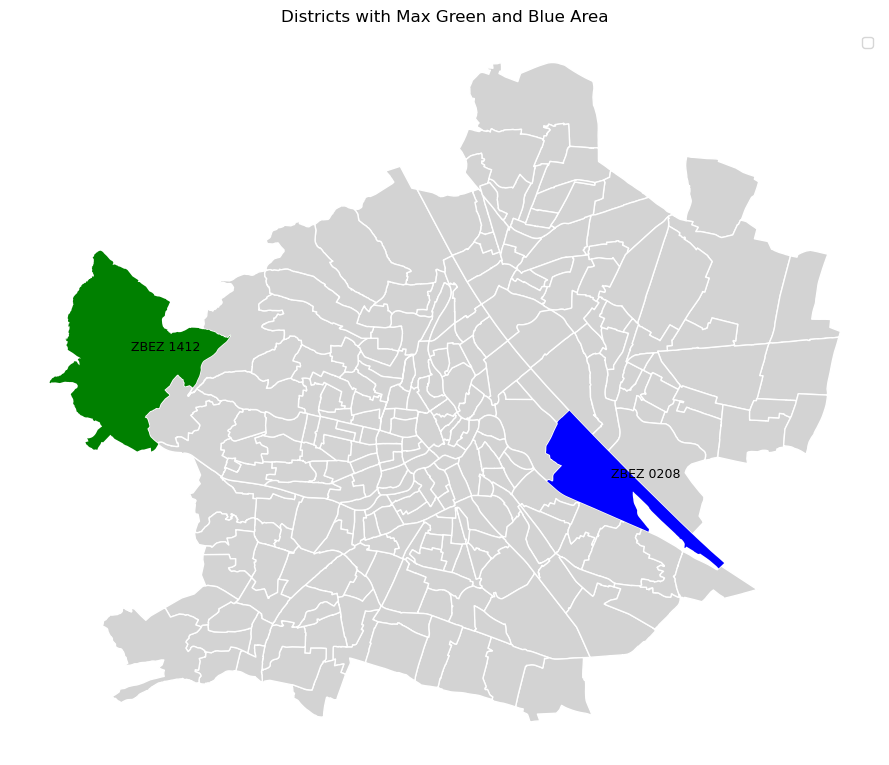

In [50]:
# Get the rows with max green and blue area
max_green = ugbs_socioecon_census.loc[ugbs_socioecon_census["new_green_area"].idxmax()]
max_blue = ugbs_socioecon_census.loc[ugbs_socioecon_census["blue_new_area"].idxmax()]

# Create a new GeoDataFrame with only those two
highlight_districts = gpd.GeoDataFrame([max_green, max_blue], 
                                       geometry='ssi_geometry', 
                                       crs=ugbs_socioecon_census.crs)


# Plot all districts
fig, ax = plt.subplots(1, 1, figsize=(9, 9))
ugbs_socioecon_census.plot(ax=ax, color='lightgrey', edgecolor='white')

# Highlight max green area
highlight_districts[highlight_districts['ZBEZ'] == max_green['ZBEZ']].plot(ax=ax, color='green', label='Max Green Area')

# Highlight max blue area
highlight_districts[highlight_districts['ZBEZ'] == max_blue['ZBEZ']].plot(ax=ax, color='blue', label='Max Blue Area')

for idx, row in highlight_districts.iterrows():
    plt.annotate(
        text=f"ZBEZ {row['ZBEZ']}", 
        xy=(row['ssi_geometry'].centroid.x, row['ssi_geometry'].centroid.y), 
        xytext=(3, 3), textcoords="offset points",
        fontsize=9, color='black'
    )

# Final plot adjustments
ax.set_title("Districts with Max Green and Blue Area", fontsize=12)
ax.axis("off")
plt.legend()
plt.tight_layout()
plt.savefig("output/02Maps/vienna_max_green_blue_area_census.png", dpi=300)
plt.show()

In [51]:
print(type(ugbs_socioecon_census))
ugbs_socioecon_census.to_file("dataframes/ugbs_socioecon_census_final.geojson", driver="GeoJSON")

<class 'geopandas.geodataframe.GeoDataFrame'>


In [52]:
gdf_green.to_file("dataframes/urban_green_spaces.geojson", driver="GeoJSON")
blue_areas_total.to_file("dataframes/urban_blue_spaces.geojson", driver="GeoJSON")

## Other Data

### District data
* ugbs_socioecon_census gdf contains socio-economic variables & ugbs all for census scale
* District data is area, circumference, geometry and name
* Census district data is aggregated based on their location and for every district, socio-economic variables' values found

In [53]:
districts = gpd.read_file('data/vienna_districts.geojson') # districts data from GIS course hw2

districts = districts.rename(columns={
    'UMFANG': 'circumference',
    'FLAECHE': 'area'
})

print(districts.crs)
districts.head(3)

EPSG:4326


,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,STATAUSTR0,area,circumference,AKT_TIMEST,SE_SDO_ROW,geometry
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,91301.0,3.771397e+07,29668.16,2023-07-18,13126.0,"POLYGON ((16.21423 48.20652, 16.21425 48.20651..."
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,91501.0,3.916953e+06,9711.71,2023-07-18,13127.0,"POLYGON ((16.32732 48.205, 16.33366 48.20406, ..."
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,90701.0,1.608248e+06,5312.54,2023-07-18,13128.0,"POLYGON ((16.33873 48.20854, 16.33901 48.20849..."


In [54]:
# Spatial join in order to find socio-economic indicators in district scale as well. 
# This will be used later on to understand whether i can use average income as a proxy for rental prices or not.

districts = districts.to_crs(ugbs_socioecon_census.crs)
print(districts.crs)
# Attaching district info to each census district
gdf_joined = gpd.sjoin(ugbs_socioecon_census, districts[['geometry', 'NAMEK_NUM']], how='left', predicate='intersects')
print(len(gdf_joined))
gdf_joined.head(3)

EPSG:31256
516


,ZBEZ,census_boundaries_area,new_green_area,green_ratio,blue_new_area,blue_ratio,university_share,avg_income,employment,benefit_share,SSI,quintile,ssi_geometry,area_ssi,greenblue_ratio,index_right,NAMEK_NUM
0,0101,377461.659643,1177.028363,0.003118,16.971625,0.000045,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,"POLYGON ((3485.019 341498.126, 3484.459 341498...",377557.211380,0.003163,8,"2., Leopoldstadt"
0,0101,377461.659643,1177.028363,0.003118,16.971625,0.000045,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,"POLYGON ((3485.019 341498.126, 3484.459 341498...",377557.211380,0.003163,5,"1., Innere Stadt"
1,0102,379376.751348,77665.401597,0.204718,56987.074366,0.150212,1.653812,2.565233,1.237000,1.139440,2.000434,5.0,"POLYGON ((3487.789 341009.066, 3470.019 341017...",379376.751386,0.354931,3,"3., Landstraße"


In [55]:
# Group by district name and taking the average
socio_vars = ['avg_income', 'employment', 'university_share', 'benefit_share', 'SSI']  # all socio-economic variables
district_stats = gdf_joined.groupby('NAMEK_NUM')[socio_vars].mean().reset_index()
district_stats.rename(columns={
    'avg_income': 'district_avgincome',
    'employment': 'district_employment',
    'university_share': 'district_univshare',
    'benefit_share': 'district_benefitshare',
    'SSI': 'district_SSI'
}, inplace=True)

socioecon_districts = districts.merge(district_stats, on='NAMEK_NUM', how='left')

In [56]:
print(socioecon_districts.crs)
print(len(socioecon_districts))
socioecon_districts.head(3)

EPSG:31256
23


,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,area,circumference,AKT_TIMEST,SE_SDO_ROW,geometry,district_avgincome,district_employment,district_univshare,district_benefitshare,district_SSI
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,3.771397e+07,29668.16,2023-07-18,13126.0,"POLYGON ((-8763.201 340909.446, -8762.391 3409...",0.642256,0.369003,0.549082,0.285477,0.561803
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,3.916953e+06,9711.71,2023-07-18,13127.0,"POLYGON ((-357.525 340733.412, 113.603 340627....",-0.624444,-0.296566,0.141626,-0.112714,-0.254327
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,1.608248e+06,5312.54,2023-07-18,13128.0,"POLYGON ((489.859 341126.146, 511.359 341120.7...",0.409909,0.407823,1.101009,0.588805,0.743321


In [57]:
print(type(socioecon_districts))
socioecon_districts.to_file("dataframes/socioecon_districts.geojson", driver="GeoJSON")

<class 'geopandas.geodataframe.GeoDataFrame'>


### Housing Prices Data
District Scale

In [58]:
housing_path = "data/SpecialEvaluation.ods" 
housing_data = pd.read_excel(housing_path, engine="odf", sheet_name=None)

# Show available sheets
print(housing_data.keys())

dict_keys(['Apartment_Prices', 'House_Prices', 'Building_Plots', 'Federal_Provinces', 'Apartment_Prices_municipalities', 'House_Prices_municipalities', 'Fed__states_and_constr__Periods'])


In [59]:
housing_data = pd.read_excel(
    housing_path,
    engine="odf",
    sheet_name="Apartment_Prices",  
    header=1                        # use row 2 as column names
)
housing_data.columns

Index(['D. CD.', 'Districts', 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023],
      dtype='object')

In [60]:
# Keep only Vienna rows, Wiener Neustadt is not in Vienna in terms of state boundaries
housing_vienna = housing_data[
    housing_data['Districts'].str.contains('Wien', na=False) &
    ~housing_data['Districts'].str.contains('Wiener Neustadt', na=False)
]
housing_vienna.columns = housing_vienna.columns.astype(str)

housing_vienna.loc[:, 'district_clean'] = housing_vienna['Districts'].str.split(',').str[1].str.strip()
housing_vienna.head(5)

/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_23168/2484245388.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  housing_vienna.loc[:, 'district_clean'] = housing_vienna['Districts'].str.split(',').str[1].str.strip()


,D. CD.,Districts,2015,2016,2017,2018,2019,2020,2021,2022,2023,district_clean
93,901,"Wien 1.,Innere Stadt",6569,7861,9368,10955,11186,10947,13078,14389,12733,Innere Stadt
94,902,"Wien 2.,Leopoldstadt",3650,4125,4327,4482,4590,5215,5331,6181,5494,Leopoldstadt
95,903,"Wien 3.,Landstraße",3934,4039,4483,4787,4375,5483,5715,5850,5635,Landstraße
96,904,"Wien 4.,Wieden",4189,4237,4932,5195,5650,5586,6471,7776,6646,Wieden
97,905,"Wien 5.,Margareten",3272,3500,3548,3662,3796,4634,5648,5440,4562,Margareten


In [61]:
# Merging housing prices data into districts GeoDataFrame
housingprices_district = districts.merge(
    housing_vienna[['district_clean', '2015', '2016', '2017', '2018', '2019', '2020',  '2021', '2022', '2023']],
    left_on='NAMEK',
    right_on='district_clean',
    how='left'
)

year_cols = ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
housingprices_district['avg_price_years'] = housingprices_district[year_cols].mean(axis=1)
housingprices_district["avg_price_years"] = pd.to_numeric(housingprices_district["avg_price_years"], errors='coerce')
housingprices_district['avg_price_years'] = housingprices_district['avg_price_years'].round(2)

In [62]:
pd.set_option('display.precision', 2)
print(housingprices_district.crs)
housingprices_district.head(3)

EPSG:31256


,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,avg_price_years
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,4232,4132,4043,4423,4462,4821,5593,6159,5327,4799.11
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,2429,3369,3315,3827,3860,4111,4729,4460,4215,3812.78
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,4774,4553,4755,5405,5833,6043,6332,6336,5929,5551.11


In [63]:
type(housingprices_district)
housingprices_district.to_file("dataframes/housingprices_district.geojson", driver="GeoJSON")

### Housing Data
* for apartments, room numbers, heating etc - features of homes per CENSUS district

In [64]:
apartment_features_path = 'data/vie_apartments_wohnungen_2021.csv'
apartment_features = pd.read_csv(apartment_features_path, delimiter=';', header=1)
apartment_features.head(3)

,NUTS1,NUTS2,NUTS3,DISTRICT_CODE,SUB_DISTRICT_CODE,WHG_TOTAL,WHG_WSA_0,WHG_WSA_1,WHG_NOC_0,WHG_NOC_1,...,OBJ_BAUP_7,OBJ_BAUP_8,OBJ_BAUP_9,OBJ_ANZWHG_1,OBJ_ANZWHG_2,OBJ_ANZWHG_3,OBJ_ANZWHG_4,OBJ_ANZWHG_5,OBJ_ANZWHG_6,REF_DATE
0,AT1,AT13,AT130,90100,90101,2686,592,2094,592,1138,...,26,0,19,25,32,235,680,930,784,20211031
1,AT1,AT13,AT130,90100,90102,945,198,747,198,354,...,4,1,9,7,6,77,299,327,229,20211031
2,AT1,AT13,AT130,90100,90103,1294,264,1030,264,491,...,25,0,16,17,32,103,428,563,151,20211031


In [65]:
apartment_features.columns = apartment_features.columns.str.strip().str.upper()

In [66]:
apt_features_final = apartment_features[[
    "DISTRICT_CODE", "SUB_DISTRICT_CODE", "WHG_TOTAL",
    "WHG_BEHEIZ_0", "WHG_BEHEIZ_1",
    "OBJ_EIGENT_1", "OBJ_EIGENT_2", "OBJ_EIGENT_3", "OBJ_EIGENT_4"
]]

apt_features_final.columns = [
    "district_code",                # DISTRICT_CODE → Municipal district code
    "census_district_code",         # SUB_DISTRICT_CODE → Census district code
    "total_flats",             # WHG_TOTAL → Total apartments 
    "no_central_heating",           # WHG_BEHEIZ_0 → No central heating
    "central_heating",              # WHG_BEHEIZ_1 → Central heating
    "owner_private",    # OBJ_EIGENT_1 → Private individual(s)
    "owner_public",    # OBJ_EIGENT_2 → Public corporations
    "owner_nonprofit",        # OBJ_EIGENT_3 → Non-profit building associations
    "owner_other"            # OBJ_EIGENT_4 → Other legal entity
]

apt_features_final.head(5)

,district_code,census_district_code,total_flats,no_central_heating,central_heating,owner_private,owner_public,owner_nonprofit,owner_other
0,90100,90101,2686,94,2592,1271,483,4,928
1,90100,90102,945,31,914,559,33,4,349
2,90100,90103,1294,34,1260,708,74,0,512
3,90100,90104,922,36,886,418,200,0,304
4,90100,90105,1302,51,1251,610,217,13,462


In [67]:
apt_features_final.to_csv("dataframes/apt_features_final_census.csv", index=False)